## ASS 2 QUESTION14

In [1]:
from ISLP import load_data
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

## Create the binary variable mpg01

In [2]:
Auto = load_data('Auto')
median_mpg = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

print("Median mpg:", median_mpg)
print(Auto['mpg01'].value_counts())

Median mpg: 22.75
mpg01
0    196
1    196
Name: count, dtype: int64


perfectly balanced because we split at the median

#### EDA

In [3]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'mpg01'],
      dtype='object')

In [4]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0


In [5]:
Auto.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
mpg01           0
dtype: int64

In [6]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   mpg01         392 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 38.7+ KB


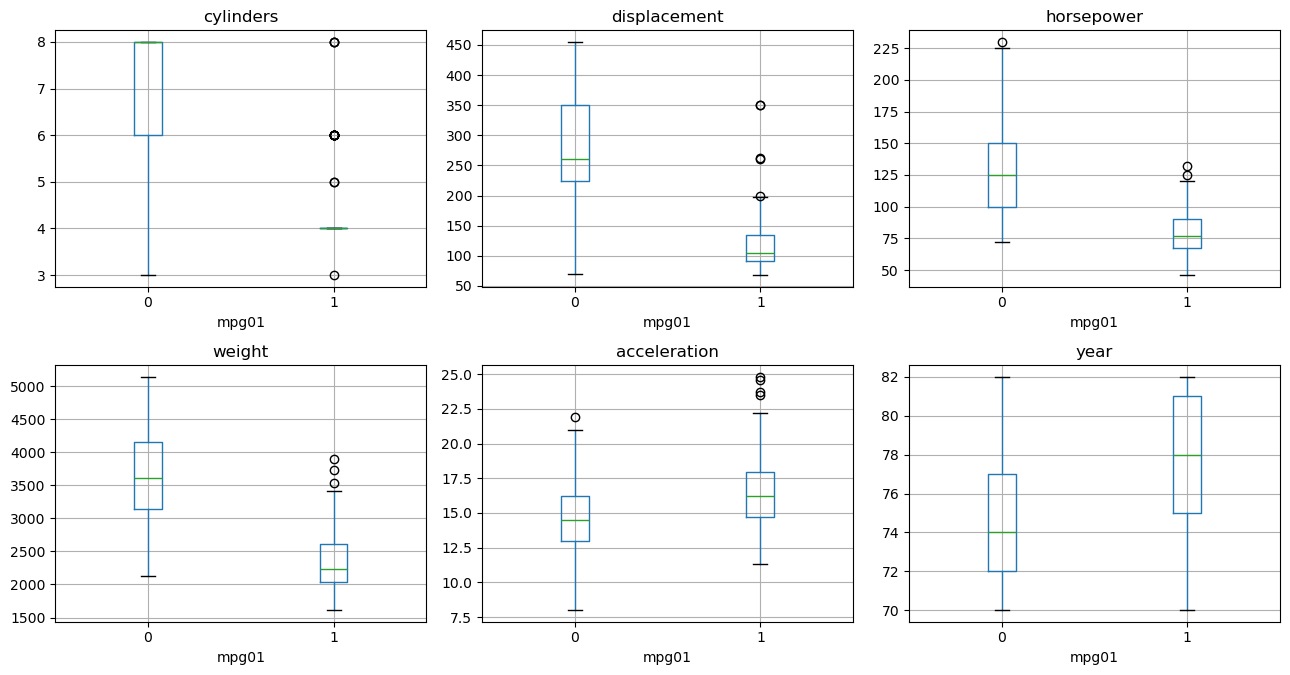

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13,7))
features_to_check = ['cylinders','displacement','horsepower','weight','acceleration','year']

for ax, feat in zip(axes.flat, features_to_check):
    Auto.boxplot(column=feat, by='mpg01', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('mpg01')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [8]:
numeric_cols = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']
print(Auto[numeric_cols + ['mpg01']].corr()['mpg01'].sort_values(ascending=False))

mpg01           1.000000
origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
Name: mpg01, dtype: float64


### Split into training and test sets

In [9]:
features = ['cylinders','displacement','horsepower','weight']
X = Auto[features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify=y keeps the 50/50 class balance intact in both splits, since mpg01 is perfectly balanced by construction and we don't want a random split to accidentally skew that.
print("Train:", len(X_train), " Test:", len(X_test))

Train: 274  Test: 118


## LDA

In [10]:
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
test_error_lda = 1 - lda.score(X_test, y_test)
print(f"LDA test error: {test_error_lda:.4f}")

LDA test error: 0.1102


## QDA

In [11]:
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
test_error_qda = 1 - qda.score(X_test, y_test)
print(f"QDA test error: {test_error_qda:.4f}")

QDA test error: 0.1017


## Logistic regression

In [13]:
logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
test_error_log = 1 - logreg.score(X_test, y_test)
print(f"test error: {test_error_log:.4f}")

test error: 0.1186


## Naive Bayes

In [15]:
nb = GaussianNB().fit(X_train, y_train)
test_error_nb = 1 - nb.score(X_test, y_test)
print(f"test error: {test_error_nb:.4f}")

test error: 0.1017


## KNN across several values of K

In [16]:
knn_errors = {}
for k in [1, 3, 5, 7, 9, 11, 15, 21, 31]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    knn_errors[k] = 1 - knn.score(X_test, y_test)

for k, err in knn_errors.items():
    print(f"K={k:3d}: test error = {err:.4f}")

best_k = min(knn_errors, key=knn_errors.get)
print(f"\nBest K: {best_k} (test error = {knn_errors[best_k]:.4f})")

K=  1: test error = 0.1441
K=  3: test error = 0.1186
K=  5: test error = 0.1102
K=  7: test error = 0.1017
K=  9: test error = 0.1186
K= 11: test error = 0.1102
K= 15: test error = 0.1102
K= 21: test error = 0.1017
K= 31: test error = 0.1186

Best K: 7 (test error = 0.1017)


QDA, Naive Bayes, and KNN (K=7 || 21) is the best model since their test error is: 10.17%   
QDA being the best than LDA suggests that four features probably don't share identical variance/covariance structure across the two mpg01